<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning </b></center>

<center><b><h1>Lab - 13</b></center>    
<pre>    


# Dataset : `Wine Dataset.csv`

# Step 1: Import Libraries
**Import the necessary libraries for data manipulation, visualization, and machine learning.**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 2: Load the Dataset
**Load the Wine dataset from Scikit-learn and explore the feature names.**

In [20]:
wine = load_wine()
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

# Step 3: Create a DataFrame
**Convert the raw data into a Pandas DataFrame for better readability and inspection.**

In [21]:
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Step 4: Statistical Summary
**Check the statistics of the dataset to understand the scale of different features (e.g., Alcohol vs.
Magnesium)**

In [22]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


# Step 5: Split the Data
**Split the dataset into Training and Testing sets (80% Train, 20% Test).**

In [23]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 6: Feature Scaling (Crucial for PCA/LDA)
**PCA and LDA are distance-based algorithms and are highly sensitive to the scale of the data.**
**UseStandardScaler to normalize features (Mean=0, Std=1)**

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Implement PCA (Principal Component Analysis)
**Apply PCA to reduce the dataset from 13 features down to 2 principal components for visualization.**

In [25]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 8: Explained Variance Ratio
**Check how much information (variance) is retained by the selected 2 principal components.**

In [27]:
print("explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\ntotal variance retained:")
print(sum(pca.explained_variance_ratio_))

explained variance ratio:
[0.35900066 0.18691934]

total variance retained:
0.54592000222866


# Step 9: Visualize PCA Results
**Plot the data points using the two new Principal Components.**

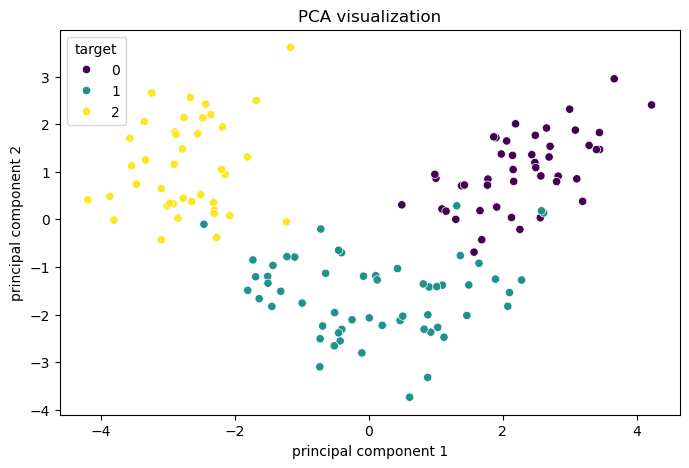

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=y_train,
    palette='viridis'
)

plt.title("PCA visualization")
plt.xlabel("principal component 1")
plt.ylabel("principal component 2")

plt.show()

# Step 10: Implement LDA (Linear Discriminant Analysis)
**Apply LDA to reduce dimensionality. Unlike PCA, LDA uses class labels (y_train) to maximize the separation between classes.**

In [30]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train_scaled,y_train)

X_test_lda = lda.transform(X_test_scaled)

# Step 11: Visualize LDA Results
**Plot the data points using the two new Linear Discriminants. Compare this plot with the PCA plot.**

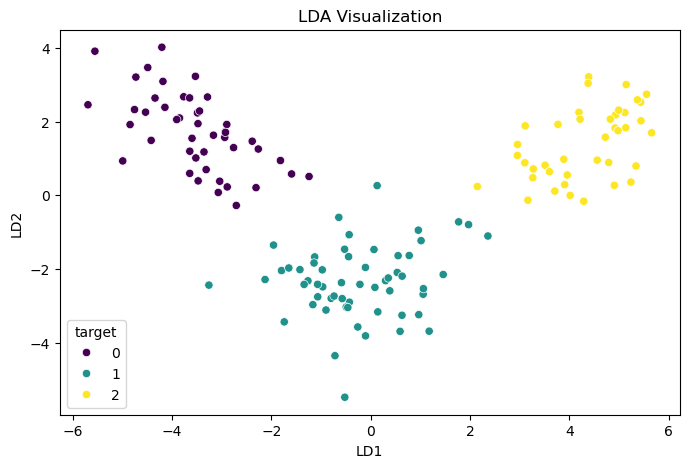

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_train_lda[:,0],
    y=X_train_lda[:,1],
    hue=y_train,
    palette='viridis')

plt.title("LDA Visualization")
plt.xlabel("LD1")
plt.ylabel("LD2")

plt.show()

# Step 12: Feature Selection - Filter Method (SelectKBest)
**Select the top 5 most important features using ANOVA F-value (f_classif).**

In [32]:
selector = SelectKBest(score_func=f_classif,k=5)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['alcohol', 'flavanoids', 'color_intensity',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


# Step 13: Feature Selection - Wrapper Method (RFE)
**Use Recursive Feature Elimination (RFE) with a Logistic Regression estimator to find the best 5 features**

In [33]:
lr = LogisticRegression(max_iter=5000)

rfe = RFE(estimator=lr,n_features_to_select=5)

rfe.fit(X, y)

rfe_features = X.columns[rfe.support_]

print("Best 5 Features (RFE):")
print(rfe_features)

Best 5 Features (RFE):
Index(['alcohol', 'ash', 'flavanoids', 'color_intensity',
       'od280/od315_of_diluted_wines'],
      dtype='object')


# Step 14: Feature Selection - Embedded Method (Random Forest)
**Train a Random Forest Classifier and use its built-in feature_importances_ attribute.**

In [34]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': importance})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

feature_importance

,Feature,Importance
6,flavanoids,0.194481
9,color_intensity,0.172961
0,alcohol,0.141614
12,proline,0.137045
11,od280/od315_of_diluted_wines,0.111831
10,hue,0.076939
5,total_phenols,0.035080
1,malic_acid,0.033060
3,alcalinity_of_ash,0.029885
4,magnesium,0.025873


# 15.Step 15: Visualize Feature Importance
**Create a bar plot to visualize which features contribute the most to the classification.**

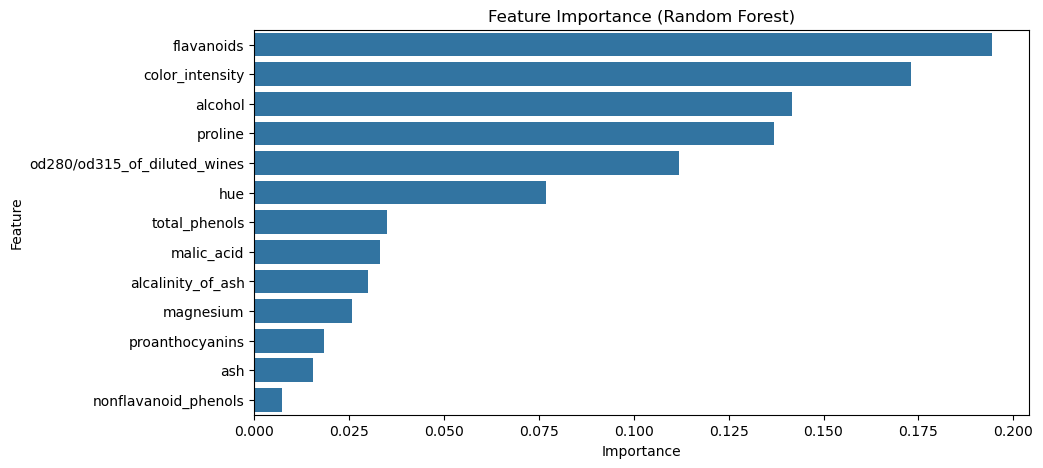

In [35]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance)

plt.title("Feature Importance (Random Forest)")
plt.show()

# 16.Step 16: Model Comparison (Optional/Bonus)
**Train a simple Classifier (e.g., Logistic Regression) on the Original Data vs. PCA Data vs. LDA Data and compare accuracy.**

In [36]:
# original data
lr_original = LogisticRegression(max_iter=5000)

lr_original.fit(X_train_scaled,y_train)

pred_original = lr_original.predict(X_test_scaled)

acc_original = accuracy_score(y_test,pred_original)

print("Original Accuracy:", acc_original)

Original Accuracy: 1.0


In [37]:
# pca data
lr_pca = LogisticRegression(max_iter=5000)

lr_pca.fit(X_train_pca,y_train)

pred_pca = lr_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test,pred_pca)

print("PCA Accuracy:", acc_pca)

PCA Accuracy: 1.0


In [38]:
# lda data

In [39]:
lr_lda = LogisticRegression(max_iter=5000)

lr_lda.fit(X_train_lda,y_train)

pred_lda = lr_lda.predict(X_test_lda)

acc_lda = accuracy_score(y_test,pred_lda)

print("LDA Accuracy:", acc_lda)

LDA Accuracy: 1.0
